변경 o

# Baseline

In [78]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

Read dataset files

In [79]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [80]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            300000 non-null  int64  
 1   Hospital                           300000 non-null  int64  
 2   Hospital_type                      300000 non-null  int64  
 3   Hospital_city                      300000 non-null  int64  
 4   Hospital_region                    300000 non-null  int64  
 5   Available_Extra_Rooms_in_Hospital  300000 non-null  int64  
 6   Department                         300000 non-null  object 
 7   Ward_Type                          300000 non-null  object 
 8   Ward_Facility                      300000 non-null  object 
 9   Bed_Grade                          299897 non-null  float64
 10  patientid                          300000 non-null  int64  
 11  City_Code_Patient                  2957

In [81]:
train_df.Class.value_counts()

0    178399
1     95881
2     25720
Name: Class, dtype: int64

Make dataset

In [82]:
train_df = train_df.dropna()
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]
X_test = test_df


print(len(X_train), len(X_test), len(y_train))

295649 18144 295649


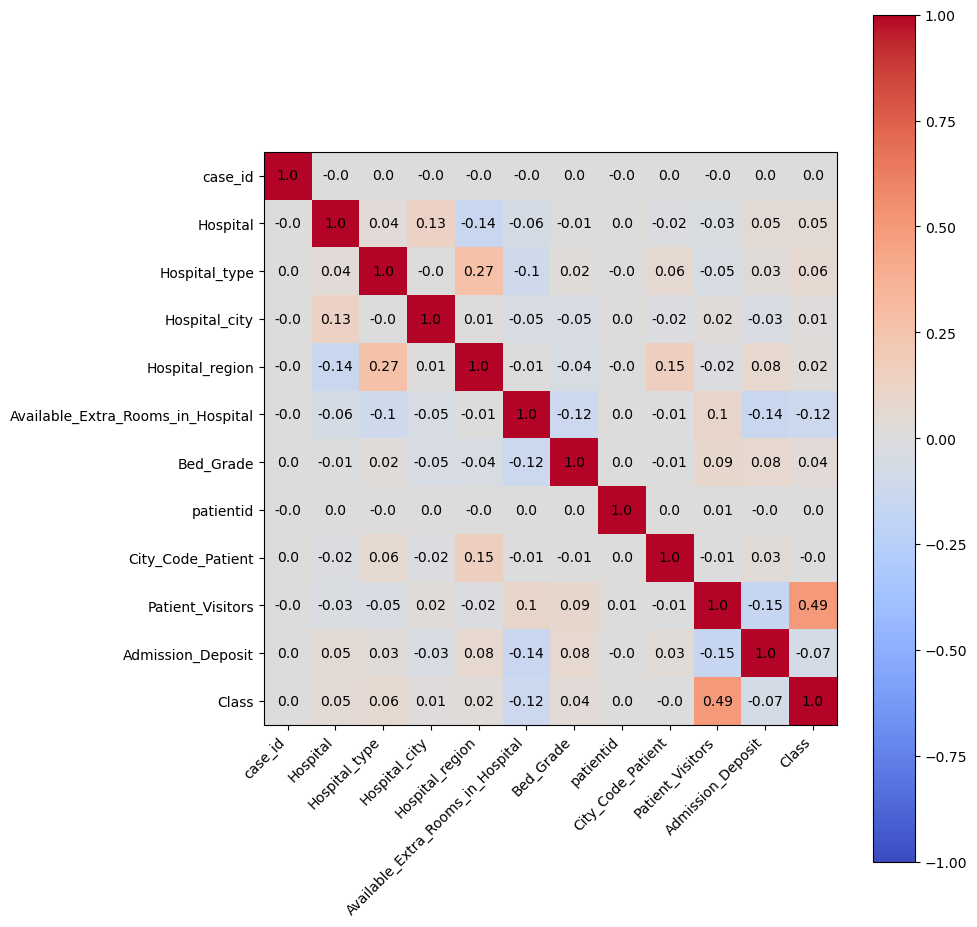

In [83]:
import matplotlib.pyplot as plt

df_corr = train_df.corr()
plt.figure(figsize=(10, 10))

plt.imshow(df_corr, cmap='coolwarm', vmin=-1, vmax=1)

plt.xticks(range(len(df_corr.columns)), df_corr.columns, rotation=45, ha='right')
plt.yticks(range(len(df_corr.columns)), df_corr.columns)

for i in range(len(df_corr.columns)) :
    for j in range(len(df_corr.columns)) :
        text = round(df_corr.iloc[i,j],2)
        plt.annotate(text, xy=(j,i), ha='center', va='center')

plt.colorbar()
plt.tight_layout()
plt.show()

In [84]:
train_df.head()

,case_id,Hospital,Hospital_type,Hospital_city,Hospital_region,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility,Bed_Grade,patientid,City_Code_Patient,Type of Admission,Illness_Severity,Patient_Visitors,Age,Admission_Deposit,Class
0,0,12,0,9,1,4,gynecology,Q,B,4.0,10295,7.0,Trauma,Minor,4,0-10,7589.0,0
1,1,6,0,6,0,3,gynecology,Q,F,1.0,101514,15.0,Trauma,Moderate,3,61-70,5625.0,1
2,2,18,3,13,1,2,anesthesia,R,B,4.0,79233,23.0,Trauma,Extreme,2,51-60,4421.0,0
3,3,19,0,7,1,4,radiotherapy,Q,C,1.0,23871,8.0,Emergency,Moderate,4,51-60,4003.0,0
4,4,30,2,3,2,3,gynecology,Q,A,2.0,125694,1.0,Emergency,Moderate,4,41-50,3864.0,0


In [85]:
from sklearn.model_selection import train_test_split

X = pd.concat([X_train, X_test], axis=0)
X = pd.get_dummies(X)

X_train = X.iloc[:len(X_train)]
X_test = X.iloc[len(X_train):]
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=0)

In [86]:
X_train.head()

,case_id,Hospital,Hospital_type,Hospital_city,Hospital_region,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Patient_Visitors,...,Age_0-10,Age_11-20,Age_21-30,Age_31-40,Age_41-50,Age_51-60,Age_61-70,Age_71-80,Age_81-90,Age_91-100
263514,263514,30,2,3,2,2,3.0,102069,13.0,2,...,0,1,0,0,0,0,0,0,0,0
155253,155253,25,4,1,0,1,3.0,98679,1.0,3,...,0,0,0,0,0,0,1,0,0,0
104117,104117,11,1,2,1,4,4.0,24781,8.0,4,...,0,0,0,1,0,0,0,0,0,0
575,575,19,0,7,1,4,1.0,99556,7.0,3,...,0,0,0,0,1,0,0,0,0,0
286837,286837,27,0,7,1,3,3.0,130398,8.0,5,...,0,0,0,0,0,0,1,0,0,0


Make model & train

In [87]:
model = RandomForestClassifier(n_estimators=100, bootstrap=True, oob_score=False, max_samples=None, random_state=0)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

Make test prediction

In [88]:
from sklearn.metrics import classification_report

test_pred = model.predict(X_test)

val_pred = model.predict(X_val)
print(classification_report(y_val, val_pred))

              precision    recall  f1-score   support

           0       0.77      0.94      0.84     17543
           1       0.66      0.49      0.56      9422
           2       0.74      0.32      0.45      2600

    accuracy                           0.74     29565
   macro avg       0.72      0.58      0.62     29565
weighted avg       0.73      0.74      0.72     29565



Export prediction to file

In [89]:
submission_df = pd.read_csv('sample_submission.csv')
submission_df.Class = test_pred
submission_df.to_csv('submission.csv', index=False)